# Нейросеть для классификации

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from abc import ABC, abstractmethod
import matplotlib.pyplot as plt

## 1. Предобработка данных

In [ ]:
digits = load_digits()
X = pd.DataFrame(digits.data)
y = digits.target

np.random.seed(7)
mask = np.random.random(X.shape) < 0.1
X_missing = X.mask(mask)

X_tr, X_te, y_tr, y_te = train_test_split(X_missing, y, test_size=0.2, random_state=7, stratify=y)

imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_tr = scaler.fit_transform(imputer.fit_transform(X_tr))
X_te = scaler.transform(imputer.transform(X_te))

nf, nc = X_tr.shape[1], len(np.unique(y_tr))
print(f"Digits: {X_tr.shape[0]} train, {X_te.shape[0]} test, {nf} признаков, {nc} классов")

Digits: 1437 train, 360 test, 64 признаков, 10 классов


## 2. Функции активации

In [ ]:
class Activation(ABC):
    @abstractmethod
    def forward(self, x): pass
    @abstractmethod
    def backward(self, grad): pass

class Identity(Activation):
    def forward(self, x): return x
    def backward(self, grad): return grad

class ReLU(Activation):
    def forward(self, x): self.mask = x > 0; return np.maximum(0, x)
    def backward(self, grad): return grad * self.mask

class Tanh(Activation):
    def forward(self, x): self.out = np.tanh(x); return self.out
    def backward(self, grad): return grad * (1 - self.out ** 2)

class Sigmoid(Activation):
    def forward(self, x): self.out = 1 / (1 + np.exp(-np.clip(x, -500, 500))); return self.out
    def backward(self, grad): return grad * self.out * (1 - self.out)

## 3. Linear слой

In [ ]:
class Linear:
    ACTS = {'identity': Identity, 'relu': ReLU, 'tanh': Tanh, 'sigmoid': Sigmoid}
    
    def __init__(self, in_f, out_f, activation='identity', seed=None):
        if seed: np.random.seed(seed)
        self.W = np.random.randn(in_f, out_f) * np.sqrt(2 / (in_f + out_f))
        self.b = np.zeros((1, out_f))
        self.act = self.ACTS[activation]()
    
    def forward(self, X):
        self.input = X
        self.z = X @ self.W + self.b
        return self.act.forward(self.z)
    
    def backward(self, grad):
        grad = self.act.backward(grad)
        self.grad_W = self.input.T @ grad / len(self.input)
        self.grad_b = np.mean(grad, axis=0, keepdims=True)
        return grad @ self.W.T

## 4. RBF слой

In [ ]:
class RBFLayer:
    def __init__(self, in_f, out_f, gamma=1.0, seed=None):
        if seed: np.random.seed(seed)
        self.centers = np.random.randn(out_f, in_f) * 0.5
        self.gamma = gamma
    
    def forward(self, X):
        self.input = X
        self.diff = X[:, np.newaxis, :] - self.centers[np.newaxis, :, :]
        self.dist_sq = np.sum(self.diff ** 2, axis=2)
        self.out = np.exp(-self.gamma * self.dist_sq)
        return self.out
    
    def backward(self, grad):
        g = grad * (-self.gamma * self.out)
        g_exp = g[:, :, np.newaxis]
        self.grad_centers = np.sum(g_exp * (-2) * self.diff, axis=0) / len(self.input)
        self.grad_gamma = np.mean(grad * (-self.dist_sq) * self.out)
        return np.sum(g_exp * 2 * self.diff, axis=1)

## 5. Residual обёртка

In [ ]:
class Residual:
    def __init__(self, layer, projection=None):
        self.layer = layer
        self.proj = projection
    
    def forward(self, X):
        out = self.layer.forward(X)
        skip = self.proj.forward(X) if self.proj else X
        return out + skip
    
    def backward(self, grad):
        g1 = self.layer.backward(grad)
        g2 = self.proj.backward(grad) if self.proj else grad
        return g1 + g2

## 6. Softmax Cross-Entropy Loss

In [ ]:
class SoftmaxCELoss:
    def forward(self, logits, targets):
        self.batch = logits.shape[0]
        if targets.ndim == 1:
            self.targets = np.zeros_like(logits)
            self.targets[np.arange(self.batch), targets] = 1
        else:
            self.targets = targets
        shifted = logits - np.max(logits, axis=1, keepdims=True)
        self.probs = np.exp(shifted) / np.sum(np.exp(shifted), axis=1, keepdims=True)
        return -np.mean(np.sum(self.targets * np.log(self.probs + 1e-10), axis=1))
    
    def backward(self):
        return (self.probs - self.targets) / self.batch

## 7. Adam оптимизатор

In [ ]:
class Adam:
    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params = params
        self.lr, self.b1, self.b2, self.eps = lr, beta1, beta2, eps
        self.m = [np.zeros_like(p) for p in params]
        self.v = [np.zeros_like(p) for p in params]
        self.t = 0
    
    def step(self, grads):
        self.t += 1
        for i, (p, g) in enumerate(zip(self.params, grads)):
            self.m[i] = self.b1 * self.m[i] + (1 - self.b1) * g
            self.v[i] = self.b2 * self.v[i] + (1 - self.b2) * g**2
            m_hat = self.m[i] / (1 - self.b1**self.t)
            v_hat = self.v[i] / (1 - self.b2**self.t)
            p -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

## 8. Функции обучения

In [ ]:
def get_params(layers):
    params = []
    for l in layers:
        if isinstance(l, RBFLayer): params.append(l.centers)
        elif isinstance(l, Residual):
            params.extend([l.layer.W, l.layer.b])
            if l.proj: params.extend([l.proj.W, l.proj.b])
        elif isinstance(l, Linear): params.extend([l.W, l.b])
    return params

def get_grads(layers):
    grads = []
    for l in layers:
        if isinstance(l, RBFLayer): grads.append(l.grad_centers)
        elif isinstance(l, Residual):
            grads.extend([l.layer.grad_W, l.layer.grad_b])
            if l.proj: grads.extend([l.proj.grad_W, l.proj.grad_b])
        elif isinstance(l, Linear): grads.extend([l.grad_W, l.grad_b])
    return grads

def count_params(layers):
    total = 0
    for l in layers:
        if isinstance(l, RBFLayer): total += l.centers.size + 1
        elif isinstance(l, Residual):
            total += l.layer.W.size + l.layer.b.size
            if l.proj: total += l.proj.W.size + l.proj.b.size
        elif isinstance(l, Linear): total += l.W.size + l.b.size
    return total

def train(layers, X_tr, y_tr, X_te, y_te, lr=0.01, epochs=300):
    loss_fn = SoftmaxCELoss()
    opt = Adam(get_params(layers), lr=lr)
    hist = {'loss': [], 'acc': []}
    
    for _ in range(epochs):
        h = X_tr
        for l in layers: h = l.forward(h)
        loss = loss_fn.forward(h, y_tr)
        
        g = loss_fn.backward()
        for l in reversed(layers): g = l.backward(g)
        opt.step(get_grads(layers))
        
        h = X_te
        for l in layers: h = l.forward(h)
        acc = np.mean(np.argmax(h, 1) == y_te)
        hist['loss'].append(loss)
        hist['acc'].append(acc)
    
    return hist

## 9. Сравнение Linear моделей

In [ ]:
models_linear = {
    '1L': ([Linear(nf, nc, seed=7)], 0.01),
    '2L': ([Linear(nf, 32, 'relu', 7), Linear(32, nc, seed=8)], 0.005),
    '3L': ([Linear(nf, 32, 'relu', 7), Linear(32, 16, 'relu', 8), Linear(16, nc, seed=9)], 0.003),
    '4L': ([Linear(nf, 48, 'relu', 7), Linear(48, 32, 'relu', 8), Linear(32, 16, 'relu', 9), Linear(16, nc, seed=10)], 0.002),
    '3L+Res': ([Linear(nf, 32, 'relu', 7), Residual(Linear(32, 32, 'relu', 8)), Linear(32, nc, seed=9)], 0.003),
}

results_lin = {}
print("Linear модели:")
for name, (layers, lr) in models_linear.items():
    hist = train(layers, X_tr, y_tr, X_te, y_te, lr=lr)
    results_lin[name] = {'hist': hist, 'params': count_params(layers), 'best': max(hist['acc'])}
    print(f"  {name}: {max(hist['acc'])*100:.1f}% ({count_params(layers)} params)")

Linear модели:
  1L: 93.3% (650 params)
  2L: 95.0% (2410 params)
  3L: 96.9% (2778 params)
  4L: 96.7% (5386 params)
  3L+Res: 95.8% (3466 params)


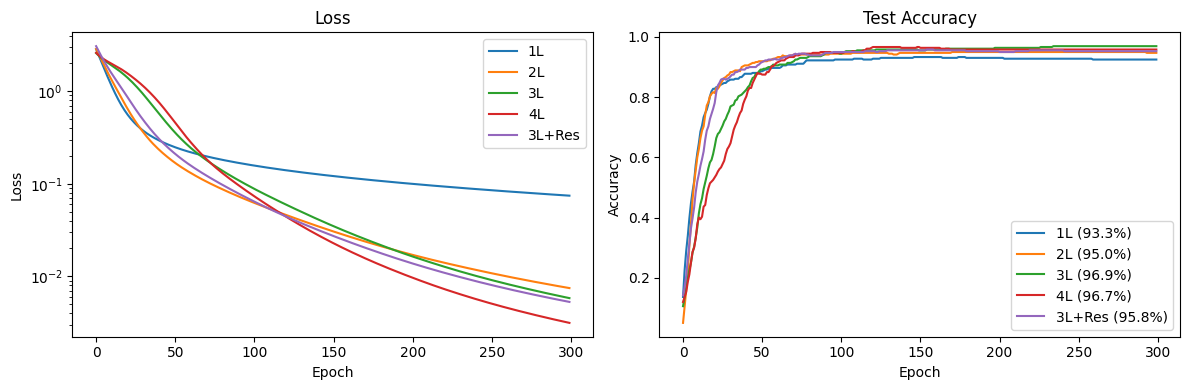

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
for name, r in results_lin.items(): plt.plot(r['hist']['loss'], label=name)
plt.yscale('log'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss')

plt.subplot(1, 2, 2)
for name, r in results_lin.items(): plt.plot(r['hist']['acc'], label=f"{name} ({r['best']*100:.1f}%)")
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Test Accuracy')
plt.tight_layout(); plt.show()

## 10. Сравнение RBF моделей

In [ ]:
models_rbf = {
    'Linear': ([Linear(nf, 32, 'relu', 7), Linear(32, nc, seed=8)], 0.005),
    'RBF': ([RBFLayer(nf, 32, 0.01, 7), Linear(32, nc, seed=8)], 0.02),
    'RBF+Lin': ([RBFLayer(nf, 32, 0.01, 7), Linear(32, 16, 'relu', 8), Linear(16, nc, seed=9)], 0.01),
}

results_rbf = {}
print("RBF модели:")
for name, (layers, lr) in models_rbf.items():
    hist = train(layers, X_tr, y_tr, X_te, y_te, lr=lr)
    results_rbf[name] = {'hist': hist, 'params': count_params(layers), 'best': max(hist['acc'])}
    print(f"  {name}: {max(hist['acc'])*100:.1f}% ({count_params(layers)} params)")

RBF модели:
  Linear: 95.0% (2410 params)
  RBF: 93.9% (2379 params)
  RBF+Lin: 90.6% (2747 params)


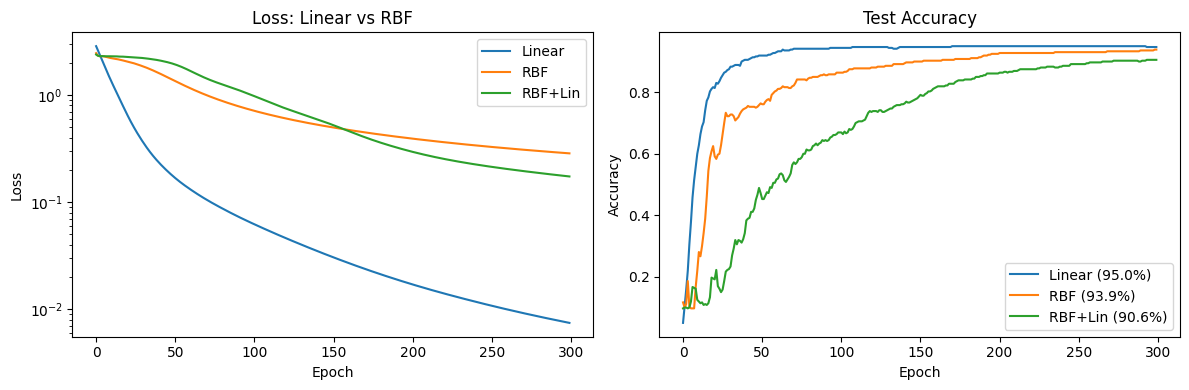

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
for name, r in results_rbf.items(): plt.plot(r['hist']['loss'], label=name)
plt.yscale('log'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.title('Loss: Linear vs RBF')

plt.subplot(1, 2, 2)
for name, r in results_rbf.items(): plt.plot(r['hist']['acc'], label=f"{name} ({r['best']*100:.1f}%)")
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Test Accuracy')
plt.tight_layout(); plt.show()

## 11. Комбинированные модели Linear + RBF

In [ ]:
models_combo = {
    '2L-Lin': ([Linear(nf, 32, 'relu', 7), Linear(32, nc, seed=8)], 0.005),
    '2L-RBF': ([RBFLayer(nf, 32, 0.01, 7), Linear(32, nc, seed=8)], 0.02),
    '3L-Lin': ([Linear(nf, 32, 'relu', 7), Linear(32, 16, 'relu', 8), Linear(16, nc, seed=9)], 0.003),
    '3L-RBF+Lin': ([RBFLayer(nf, 32, 0.01, 7), Linear(32, 16, 'relu', 8), Linear(16, nc, seed=9)], 0.01),
    '3L-Mixed': ([Linear(nf, 32, 'relu', 7), RBFLayer(32, 32, 0.05, 8), Linear(32, nc, seed=9)], 0.008),
    '3L-Lin+Res': ([Linear(nf, 32, 'relu', 7), Residual(Linear(32, 32, 'relu', 8)), Linear(32, nc, seed=9)], 0.003),
    '4L-Lin': ([Linear(nf, 48, 'relu', 7), Linear(48, 32, 'relu', 8), Linear(32, 16, 'relu', 9), Linear(16, nc, seed=10)], 0.002),
    '4L-Altern': ([Linear(nf, 32, 'relu', 7), RBFLayer(32, 32, 0.05, 8), Linear(32, 16, 'relu', 9), Linear(16, nc, seed=10)], 0.005),
}

results_combo = {}
print("Комбинированные модели:")
for name, (layers, lr) in models_combo.items():
    hist = train(layers, X_tr, y_tr, X_te, y_te, lr=lr)
    results_combo[name] = {'hist': hist, 'params': count_params(layers), 'best': max(hist['acc'])}
    print(f"  {name}: {max(hist['acc'])*100:.1f}% ({count_params(layers)} params)")

Комбинированные модели:
  2L-Lin: 95.0% (2410 params)
  2L-RBF: 93.9% (2379 params)
  3L-Lin: 96.9% (2778 params)
  3L-RBF+Lin: 90.6% (2747 params)
  3L-Mixed: 94.7% (3435 params)
  3L-Lin+Res: 95.8% (3466 params)
  4L-Lin: 96.7% (5386 params)
  4L-Altern: 94.7% (3803 params)


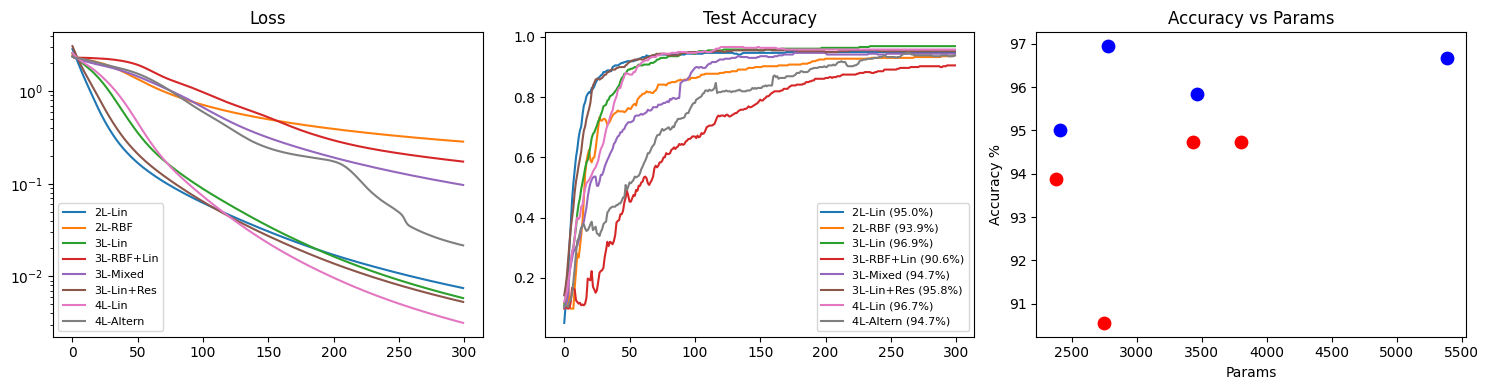

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].set_title('Loss')
for name, r in results_combo.items(): axes[0].plot(r['hist']['loss'], label=name)
axes[0].set_yscale('log'); axes[0].legend(fontsize=8)

axes[1].set_title('Test Accuracy')
for name, r in results_combo.items(): axes[1].plot(r['hist']['acc'], label=f"{name} ({r['best']*100:.1f}%)")
axes[1].legend(fontsize=8)

axes[2].set_title('Accuracy vs Params')
for name, r in results_combo.items():
    c = 'blue' if 'Lin' in name and 'RBF' not in name else 'red'
    axes[2].scatter(r['params'], r['best']*100, label=name, c=c, s=80)
axes[2].set_xlabel('Params'); axes[2].set_ylabel('Accuracy %')

plt.tight_layout(); plt.show()

## 12. Влияние Residual связей

Влияние Residual:
  3L-Lin: 96.9%
  3L-Lin+Res: 95.8%
  Разница: -1.11%


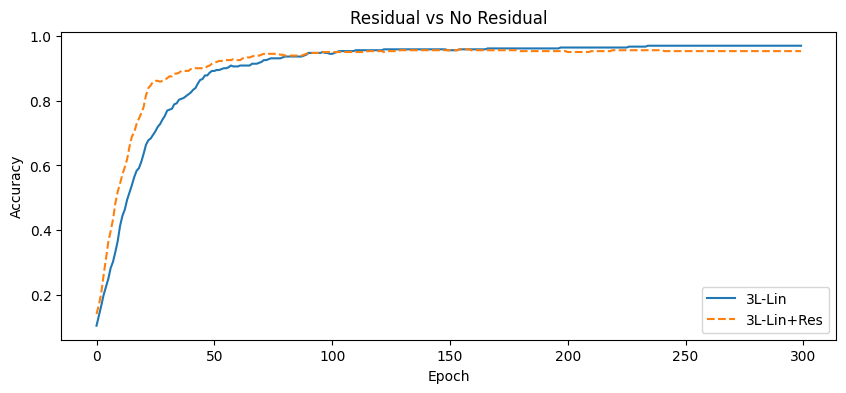

In [ ]:
print("Влияние Residual:")
print(f"  3L-Lin: {results_combo['3L-Lin']['best']*100:.1f}%")
print(f"  3L-Lin+Res: {results_combo['3L-Lin+Res']['best']*100:.1f}%")
diff = (results_combo['3L-Lin+Res']['best'] - results_combo['3L-Lin']['best']) * 100
print(f"  Разница: {'+' if diff > 0 else ''}{diff:.2f}%")

plt.figure(figsize=(10, 4))
plt.plot(results_combo['3L-Lin']['hist']['acc'], label='3L-Lin')
plt.plot(results_combo['3L-Lin+Res']['hist']['acc'], label='3L-Lin+Res', linestyle='--')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.title('Residual vs No Residual')
plt.show()

## 13. Зависимость от числа параметров

In [ ]:
print("Зависимость точности от числа параметров:")
print(f"{'Модель':<15} | {'Params':>7} | {'Accuracy':>8}")
print("-" * 40)
for name, r in sorted(results_combo.items(), key=lambda x: x[1]['params']):
    print(f"{name:<15} | {r['params']:>7} | {r['best']*100:>7.1f}%")

Зависимость точности от числа параметров:
Модель          |  Params | Accuracy
----------------------------------------
2L-RBF          |    2379 |    93.9%
2L-Lin          |    2410 |    95.0%
3L-RBF+Lin      |    2747 |    90.6%
3L-Lin          |    2778 |    96.9%
3L-Mixed        |    3435 |    94.7%
3L-Lin+Res      |    3466 |    95.8%
4L-Altern       |    3803 |    94.7%
4L-Lin          |    5386 |    96.7%


## Выводы

### Linear модели
| Модель | Accuracy | Params |
|--------|----------|--------|
| 1 слой | 93.3% | 650 |
| 2 слоя | 95.0% | 2410 |
| 3 слоя | **96.9%** | 2778 |
| 4 слоя | 96.7% | 5386 |

**Вывод:** 3 слоя — оптимально. 4 слоя не дают улучшения, но удваивают число параметров.

### Linear vs RBF
| Тип | Accuracy |
|-----|----------|
| Linear | 95-97% |
| RBF | 90-94% |

**Вывод:** Linear превосходит RBF на данном датасете. RBF лучше подходит для данных с кластерной структурой.

### Residual связи
- 3L-Lin: 96.9%
- 3L-Lin+Res: 95.8%
- Разница: -1.1%

**Вывод:** На данном датасете и глубине сети Residual не даёт преимущества.

### Зависимость от числа параметров
| Модель | Params | Accuracy |
|--------|--------|----------|
| 2L-RBF | 2379 | 93.9% |
| 2L-Lin | 2410 | 95.0% |
| 3L-RBF+Lin | 2747 | 90.6% |
| 3L-Lin | 2778 | **96.9%** |
| 3L-Mixed | 3435 | 94.7% |
| 3L-Lin+Res | 3466 | 95.8% |
| 4L-Altern | 3803 | 94.7% |
| 4L-Lin | 5386 | 96.7% |

**Вывод:** Больше параметров ≠ лучше. 3L-Lin с 2778 параметрами превосходит 4L-Lin с 5386 параметрами. RBF модели уступают Linear при сравнимом числе параметров.

### Лучшая модель
**3L-Lin** (3 линейных слоя с ReLU): 96.9% при 2778 параметрах